In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

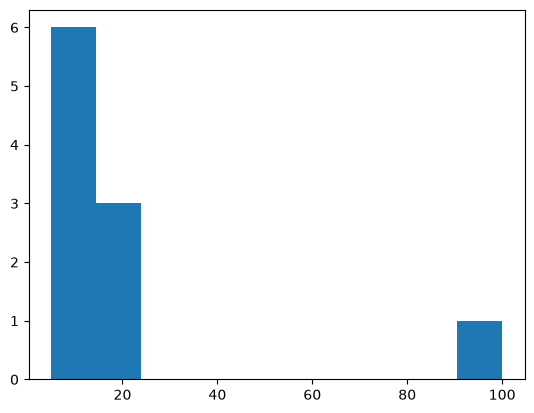

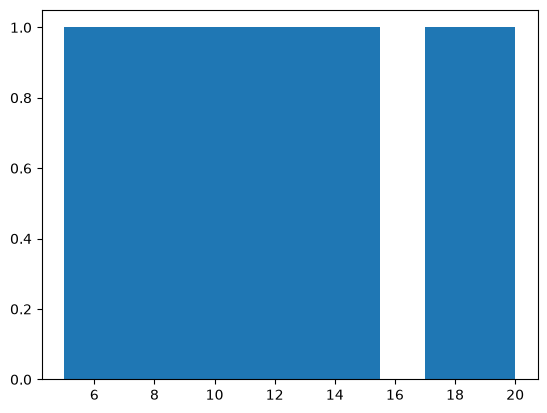

In [21]:
data = [5, 7, 8, 10, 12, 13, 15, 18, 20, 100]
plt.hist(data)
plt.show()
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_data = [x for x in data if lower <= x <= upper]
plt.hist(clean_data)
plt.show()

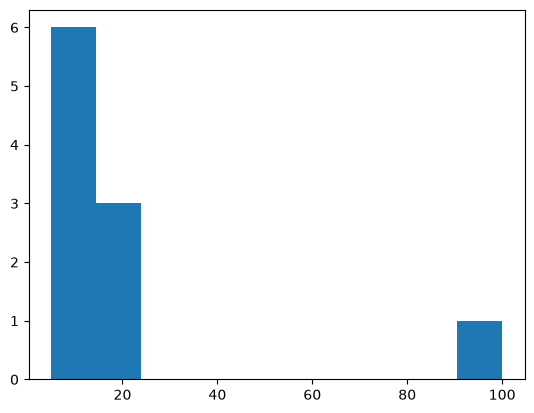

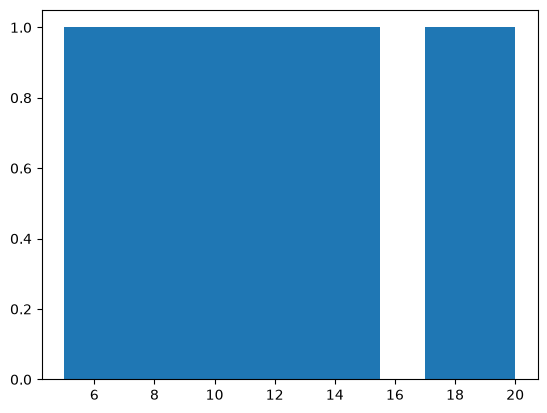

In [24]:
df = pd.DataFrame({'Data':data})
plt.hist(df['Data'])
plt.show()
q1 = df['Data'].quantile(0.25)
q3 = df['Data'].quantile(0.75)
IQR=q3-q1
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR
df_cleaned = df[(df['Data']>=lower) & (df['Data']<=upper)]
plt.hist(df_cleaned)
plt.show()

In [25]:
df["data_capped"]= df['Data'].clip(lower,upper)
df

,Data,data_capped
0,5,5.000
1,7,7.000
2,8,8.000
3,10,10.000
4,12,12.000
5,13,13.000
6,15,15.000
7,18,18.000
8,20,20.000
9,100,30.375


In [32]:
import pandas as pd

df = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 35],
    "Salary": [50000, 60000, 70000],
    "City": ["Chennai", "Delhi", "Mumbai"]
})
df

,Name,Age,Salary,City
0,Alice,25,50000,Chennai
1,Bob,30,60000,Delhi
2,Charlie,35,70000,Mumbai


In [41]:
df_cleaned = df.copy()
df_ints = df.select_dtypes(include='number')
for i in df_ints.columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    IQR=q3-q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[i]>=lower) & (df_cleaned[i]<=upper)]

In [42]:
df_cleaned

,Name,Age,Salary,City
0,Alice,25,50000,Chennai
1,Bob,30,60000,Delhi
2,Charlie,35,70000,Mumbai


In [44]:
df_cleaned = df.copy()
df_ints = df.select_dtypes(include='number')
for i in df_ints.columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    IQR=q3-q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    df_cleaned[i] = df_cleaned[i].clip(lower,upper)
df_cleaned

,Name,Age,Salary,City
0,Alice,25,50000,Chennai
1,Bob,30,60000,Delhi
2,Charlie,35,70000,Mumbai


In [45]:
data = [48, 49, 50, 51, 52, 53, 120]
df = pd.DataFrame({"Marks": data})
mean = df['Marks'].mean()
std = df['Marks'].std()
df['Marks_z_Score'] = (df['Marks']-mean)/std
df_cleaned = df[df['Marks_z_Score'].abs() <= 3]
df_cleaned.drop(columns={'Marks_z_Score'},inplace=True)
df_cleaned

,Marks,Marks_z_Score
0,48,-0.472139
1,49,-0.434150
2,50,-0.396162
3,51,-0.358174
4,52,-0.320186
5,53,-0.282198
6,120,2.263009


,Marks
0,48
1,49
2,50
3,51
4,52
5,53
6,120


In [49]:
lower_bound = mean - (3 * std)
upper_bound = mean + (3 * std)
df['Marks']=df['Marks'].clip(lower_bound,upper_bound)
df

,Marks,Marks_z_Score
0,48,-0.472139
1,49,-0.434150
2,50,-0.396162
3,51,-0.358174
4,52,-0.320186
5,53,-0.282198
6,120,2.263009


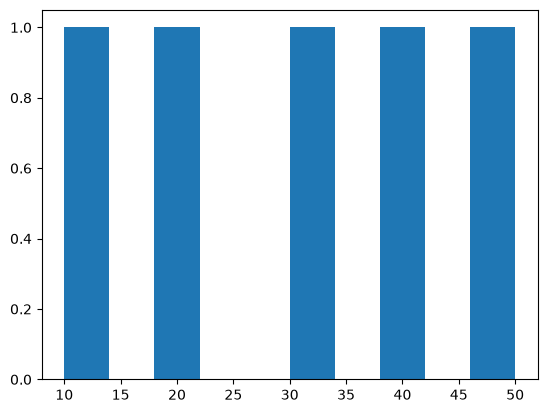

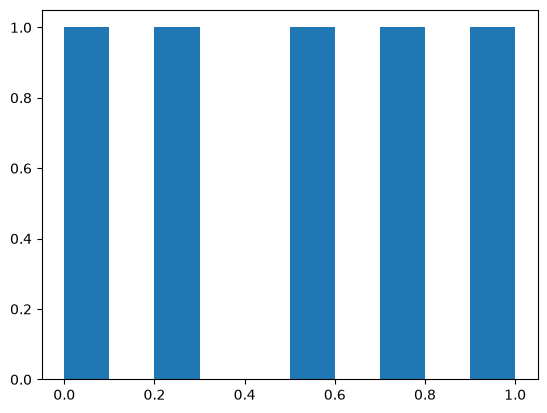

In [53]:
# Min Max Scaling:
data = [10, 20, 30, 40, 50]
plt.hist(data)
plt.show()
df = pd.DataFrame({"Data":data})
min_val =  df['Data'].min()
max_val =  df['Data'].max()
df['Data'] = (df['Data'] - min_val) / (max_val - min_val)
plt.hist(df['Data'])
plt.show()

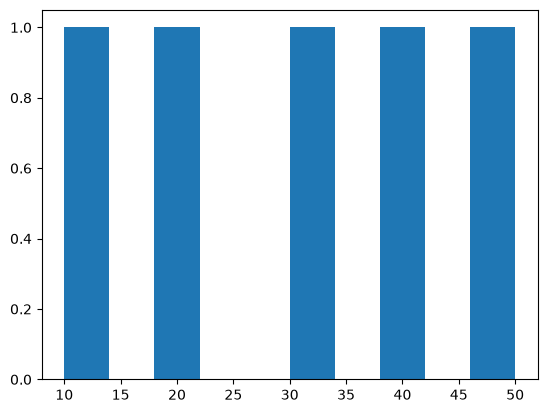

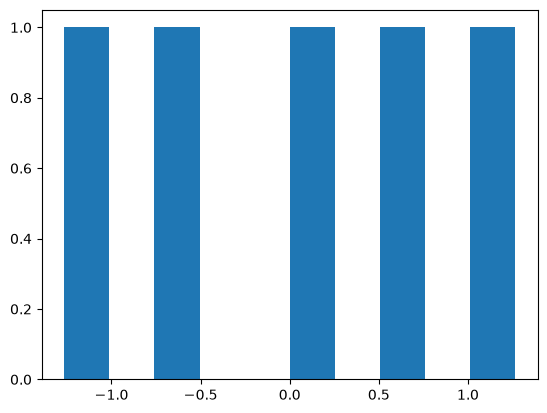

In [55]:
# Standardization : Z Score Transformation
data = [10, 20, 30, 40, 50]
df = pd.DataFrame({"Data":data})
plt.hist(df['Data'])
plt.show()
mean = df['Data'].mean()
std = df['Data'].std()
df['Data'] = (df['Data']-mean)/std
plt.hist(df['Data'])
plt.show()

In [56]:
df = pd.DataFrame({
    "Age": [20, 25, 30, 35, 40],
    "Salary": [30000, 50000, 70000, 90000, 110000],
    "Height": [150, 160, 170, 180, 190]
})
for i in df.columns:
    mean = df[i].mean()
    std = df[i].std()
    df[i] = (df[i]-mean)/std
df

,Age,Salary,Height
0,-1.264911,-1.264911,-1.264911
1,-0.632456,-0.632456,-0.632456
2,0.000000,0.000000,0.000000
3,0.632456,0.632456,0.632456
4,1.264911,1.264911,1.264911


In [58]:
#L2 Normalization
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Height": [3],
    "Weight": [4]
})

l2_norm = np.sqrt((df.iloc[0] ** 2).sum())

df_normalized = df / l2_norm

print(df_normalized)

   Height  Weight
0     0.6     0.8


In [61]:
#Multiple rows
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "X": [3, 1],
    "Y": [4, 2]
})

l2_norm = np.sqrt((df ** 2).sum(axis=1))

df_normalized = df.div(l2_norm, axis=0)

print(df_normalized)

          X         Y
0  0.600000  0.800000
1  0.447214  0.894427


In [63]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2')

df_normalized = pd.DataFrame(
    normalizer.fit_transform(df),
    columns=df.columns
)
df_normalized

,X,Y
0,0.600000,0.800000
1,0.447214,0.894427


In [64]:
df = pd.DataFrame({
    "Math": [3, 6],
    "Science": [4, 8]
})
l2_norm = np.sqrt((df **2).sum(axis=1))
df_normalized = df.div(l2_norm, axis=0)
df_normalized

,Math,Science
0,0.6,0.8
1,0.6,0.8


In [65]:
df = pd.DataFrame({
    "Math": [3, 6],
    "Science": [4, 8]
})
l2_norm = np.linalg.norm(df,axis=1)
df_normalized = df.div(l2_norm, axis=0)
df_normalized

,Math,Science
0,0.6,0.8
1,0.6,0.8


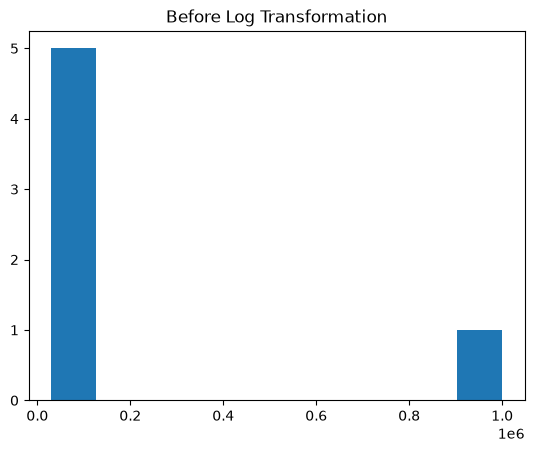

In [72]:
# Log Transformation 
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Salary": [30000, 35000, 40000, 45000, 50000, 1000000]
})

plt.hist(df["Salary"])
plt.title("Before Log Transformation")
plt.show()

In [73]:
df["Salary_Log"] = np.log(df["Salary"])
df

,Salary,Salary_Log
0,30000,10.308953
1,35000,10.463103
2,40000,10.596635
3,45000,10.714418
4,50000,10.819778
5,1000000,13.815511


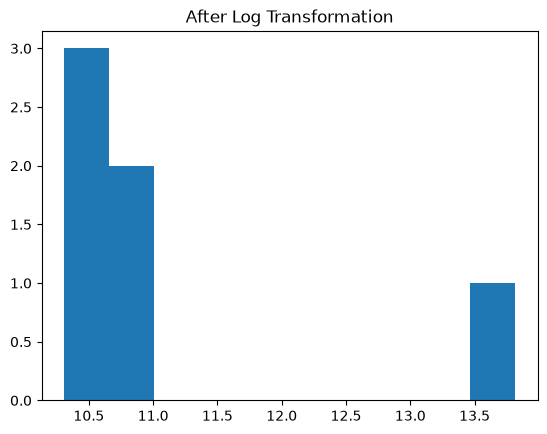

In [74]:
plt.hist(df["Salary_Log"])
plt.title("After Log Transformation")
plt.show()

In [78]:
df = pd.DataFrame({
    "Sales": [-5,0, 5, 10, 20, 50]
})
display(np.log(df['Sales']))
np.log1p(df["Sales"])

/Users/mukundanramesh/projects/ai_ml_course_bootcamp_practice/aiml_venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mukundanramesh/projects/ai_ml_course_bootcamp_practice/aiml_venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


0         NaN
1        -inf
2    1.609438
3    2.302585
4    2.995732
5    3.912023
Name: Sales, dtype: float64

/Users/mukundanramesh/projects/ai_ml_course_bootcamp_practice/aiml_venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


0         NaN
1    0.000000
2    1.791759
3    2.397895
4    3.044522
5    3.931826
Name: Sales, dtype: float64

In [ ]:
x_shifted = x - x.min() + 1

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.DataFrame({
    "Color": [
        "Red",
        "Blue",
        "Green",
        "Blue",
        "Red",
        "Green",
        "Red",
        "Blue"
    ]
})
lbl = LabelEncoder()
encoded = lbl.fit_transform(df['Color'])
df['encoded_color'] = encoded
df

,Color,encoded_color
0,Red,2
1,Blue,0
2,Green,1
3,Blue,0
4,Red,2
5,Green,1
6,Red,2
7,Blue,0


In [7]:
df = pd.DataFrame({
    "Education": [
        "Bachelor",
        "Master",
        "High School",
        "PhD",
        "Master",
        "Bachelor",
        "High School",
        "PhD"
    ]
})
order = ['High School','Bachelor','Master','PhD']
mapping = {k:i for i,k in enumerate(order)}
df['encoded_education'] = [mapping[item] for item in df['Education']]
df

,Education,encoded_education
0,Bachelor,1
1,Master,2
2,High School,0
3,PhD,3
4,Master,2
5,Bachelor,1
6,High School,0
7,PhD,3


In [11]:
df = pd.DataFrame({
    "Animal": [
        "Dog",
        "Cat",
        "Bird",
        "Dog",
        "Bird",
        "Cat",
        "Dog",
        "Cat"
    ]
})

encoded=pd.get_dummies(df['Animal'],dtype=int)
df =pd.concat([df,encoded],axis=1)
df

,Animal,Bird,Cat,Dog
0,Dog,0,0,1
1,Cat,0,1,0
2,Bird,1,0,0
3,Dog,0,0,1
4,Bird,1,0,0
5,Cat,0,1,0
6,Dog,0,0,1
7,Cat,0,1,0


In [13]:
df = pd.DataFrame({
    "Gender": [
        "Male",
        "Female",
        "Female",
        "Male",
        "Female",
        "Male"
    ],
    "Size": [
        "Small",
        "Medium",
        "Large",
        "Medium",
        "Small",
        "Large"
    ],
    "Department": [
        "HR",
        "IT",
        "Sales",
        "Finance",
        "IT",
        "Sales"
    ]
})

df['gender_label_encoded'] = lbl.fit_transform(df['Gender'])
size = ['Small','Medium','Large']
size_mapping = {k:i for i,k in enumerate(size)}
df['size_ordnial_encoded'] = [size_mapping[size] for size in df['Size']]
department_one_hot_encoded = pd.get_dummies(df['Department'],dtype=int)
df = pd.concat([df,department_one_hot_encoded],axis=1)
df

,Gender,Size,Department,gender_label_encoded,size_ordnial_encoded,Finance,HR,IT,Sales
0,Male,Small,HR,1,0,0,1,0,0
1,Female,Medium,IT,0,1,0,0,1,0
2,Female,Large,Sales,0,2,0,0,0,1
3,Male,Medium,Finance,1,1,1,0,0,0
4,Female,Small,IT,0,0,0,0,1,0
5,Male,Large,Sales,1,2,0,0,0,1


In [16]:
df = pd.DataFrame({
    "Genre": [
        "Action",
        "Comedy",
        "Drama",
        "Comedy",
        "Action",
        "Drama",
        "Sci-Fi",
        "Comedy",
        "Action"
    ],
    "Rating": [
        "Poor",
        "Average",
        "Good",
        "Excellent",
        "Good",
        "Average",
        "Excellent",
        "Poor",
        "Good"
    ],
    "Language": [
        "English",
        "Tamil",
        "Hindi",
        "English",
        "Tamil",
        "Hindi",
        "English",
        "Tamil",
        "Hindi"
    ]
})

genre_one_hot_encoded = pd.get_dummies(df['Genre'])
rating = ['Poor','Average','Good','Excellent']
rating_mapping = {k:i for i,k in enumerate(rating)}
df['rating_encoded'] = [rating_mapping[rating] for rating in df['Rating']]
df['Language_encoded'] = lbl.fit_transform(df['Language'])
concated_df = pd.concat([df,genre_one_hot_encoded],axis=1)
concated_df


,Genre,Rating,Language,rating_encoded,Language_encoded
0,Action,Poor,English,0,0
1,Comedy,Average,Tamil,1,2
2,Drama,Good,Hindi,2,1
3,Comedy,Excellent,English,3,0
4,Action,Good,Tamil,2,2
5,Drama,Average,Hindi,1,1
6,Sci-Fi,Excellent,English,3,0
7,Comedy,Poor,Tamil,0,2
8,Action,Good,Hindi,2,1
